# Tamil-English Code-Mixed Offensive Language Detection

## Dataset Loading, Preprocessing and Classical Baseline

## System Design and Pipeline Architecture



## End-to-End Pipeline Architecture: Offensive-Language Detection

**Data Ingestion**  
Official DravidianCodeMix Tamil-English dataset containing predefined train, development, and test TSV files.

↓

**Preprocessing**  
- Remove missing and empty entries
- Normalize whitespace
- Normalize excessive punctuation
- Preserve Tamil, English, code-mixed text, slang, and meaningful character elongation
- Check duplicate and repeated text
- Check cross-split overlap and label conflicts
- Preserve the official train/dev/test partitions

↓

**Representation**  
**TF-IDF Vectorization**
- Unigrams
- Bigrams

↓

**Classical Modelling**  
Two classical baseline classifiers:
- Logistic Regression
- Linear SVM

Both models use the same TF-IDF representation and official dataset splits.

↓

**Inference**  
Input text → TF-IDF representation → Classifier → Predicted offensive-language category

Possible output labels:
- `Not_offensive`
- `Offensive_Untargetede`
- `Offensive_Targeted_Insult_Individual`
- `Offensive_Targeted_Insult_Group`
- `Offensive_Targeted_Insult_Other`
- `not-Tamil`

↓

**Evaluation**  
The models are evaluated using:
- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Weighted Precision
- Weighted Recall
- Weighted F1
- Confusion Matrix
- Error Analysis


## Technology Justification

| Stage | Choice | Justification |
| --- | --- | --- |
| Representation | TF-IDF (unigrams + bigrams) | Interpretable, computationally light, and a standard, defensible baseline representation before moving to contextual embeddings; bigrams capture short negation/intensifier patterns (e.g. "not bad") that unigrams alone would miss. |
| Modelling (Model 1) | Logistic Regression | Fast to train, linear and interpretable (coefficients map directly to TF-IDF terms), and a widely accepted classical baseline for text classification. |
| Modelling (Model 2) | Linear SVM (LinearSVC) | A second linear classical baseline; comparing a probabilistic (Logistic Regression) and a margin-based (Linear SVM) classifier on the same TF-IDF features shows whether the choice of linear formulation affects performance. |
| Evaluation metric | Weighted Precision/Recall/F1 | The label distribution is imbalanced across six offensive-language categories, so weighted averaging (rather than macro or plain accuracy) reflects per-class support while still penalizing poor minority-class performance. |
| Data split | Official train/dev/test (no re-splitting) | Preserves comparability with the Transformer model trained on the same official split, avoiding an apples-to-oranges comparison. |
| Preprocessing | Minimal (whitespace/punctuation normalization only) | Aggressive cleaning (stopword removal, script normalization) risks discarding code-mixing and slang cues that are themselves predictive of offensive content in Tamil-English text. |

## 1. Install dependencies

In [5]:
%pip install -U transformers datasets accelerate evaluate scikit-learn

In [6]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

## 2. Import Libraries

Imports the libraries required for data handling, visualization, TF-IDF feature extraction, classical modeling, evaluation, and model serialization.

In [7]:
import os
import re
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Libraries imported successfully.")
print("Random seed:", SEED)

Libraries imported successfully.
Random seed: 42


## 3. Define Dataset Paths


In [8]:
DATA_DIR = "DravidianCodeMix"
TRAIN_PATH = os.path.join(DATA_DIR, "tamil_offensive_full_train.csv")
DEV_PATH = os.path.join(DATA_DIR, "tamil_offensive_full_dev.csv")
TEST_PATH = os.path.join(DATA_DIR, "tamil_offensive_full_test.csv")
print("Train:", TRAIN_PATH)
print("Dev  :", DEV_PATH)
print("Test :", TEST_PATH)

Train: DravidianCodeMix/tamil_offensive_full_train.csv
Dev  : DravidianCodeMix/tamil_offensive_full_dev.csv
Test : DravidianCodeMix/tamil_offensive_full_test.csv


## 4. Load the Dataset

In [9]:
def load_offensive_file(path):
    data = pd.read_csv(path, sep="\t", header=None, names=["text", "label", "extra"], encoding="utf-8")
    return data
train_df = load_offensive_file(TRAIN_PATH)
dev_df = load_offensive_file(DEV_PATH)
test_df = load_offensive_file(TEST_PATH)
print("Train shape:", train_df.shape)
print("Dev shape  :", dev_df.shape)
print("Test shape :", test_df.shape)

Train shape: (35139, 3)
Dev shape  : (4388, 3)
Test shape : (4392, 3)


## 5. Inspect the Raw Dataset

Displays the first few rows of each split to verify that the data loaded correctly.

In [10]:
pd.set_option("display.max_colwidth", None)
print("Training samples:")
display(train_df.head())
print("\nDevelopment samples:")
display(dev_df.head())
print("\nTest samples:")
display(test_df.head())
print("\nColumn names:")
print(train_df.columns.tolist())

Training samples:


,text,label,extra
0,movie vara level la Erika poguthu,Not_offensive,NaN
1,I love Ajith Kumar Vivegam movie inki mjy bht achi lgi,not-Tamil,NaN
2,Padam nalla comedy padama irukum polaye..,Not_offensive,NaN
3,karthick subburaj anne .... intha padam vetri adaya unagalukku ennudaya valthukkal...,Not_offensive,NaN
4,கவுண்டர் தேவர்.சார்பாக வெற்றி பெற வாழ்த்துக்கள் 🦁,Not_offensive,NaN



Development samples:


,text,label,extra
0,Handsome hunk keri vaa thalaivaa,Not_offensive,NaN
1,தென்காசி மாவட்டம் நாடார் சமுதாயம் சார்பாக வாழ்த்துக்கள்,Not_offensive,NaN
2,je vous aime bravo pour clip de merde que j écoute au toilette.,not-Tamil,NaN
3,சிறப்பு..... மேலும் இது போன்ற படைப்புகள் மிக அவசியம்....,Not_offensive,NaN
4,Vera level BGM .. semma trailer. 🤞,Not_offensive,NaN



Test samples:


,text,label,extra
0,14.12.2018 epo trailer pathutu irken ... Semaya iruku,Not_offensive,NaN
1,Paka thana poro movie la Enna irukunu,Not_offensive,NaN
2,“U kena tunggu lebih lama lagi untuk tahu saya” - chiyaan recognized,not-Tamil,NaN
3,Suriya anna vera level anna mass,Not_offensive,NaN
4,suma kaththaatha da sound over a pooda kudaathu pa s3 1 month oda stop aakidum then bairavaa da aaddchi than kaththi kaththi thondaiya kilikatha pa,Offensive_Untargetede,NaN



Column names:
['text', 'label', 'extra']


## 6. Dataset Size


In [11]:
dataset_sizes = pd.DataFrame(
    {"Split": ["Train", "Development", "Test"], "Samples": [len(train_df), len(dev_df), len(test_df)]}
)
display(dataset_sizes)

,Split,Samples
0,Train,35139
1,Development,4388
2,Test,4392


## 7. Verify the Empty Column

In [12]:
print("Non-null values in extra column:")
print("Train:", train_df["extra"].notna().sum())
print("Dev  :", dev_df["extra"].notna().sum())
print("Test :", test_df["extra"].notna().sum())

Non-null values in extra column:
Train: 0
Dev  : 0
Test : 0


## 8. Remove the Unused Column

In [13]:
train_df = train_df[["text", "label"]].copy()
dev_df = dev_df[["text", "label"]].copy()
test_df = test_df[["text", "label"]].copy()
print("Train columns:", train_df.columns.tolist())

Train columns: ['text', 'label']


## 9. Inspect the Labels

Reports the label distribution separately for the train, development, and test sets.

In [14]:
print("Training labels:")
display(train_df["label"].value_counts())
print("\nDevelopment labels:")
display(dev_df["label"].value_counts())
print("\nTest labels:")
display(test_df["label"].value_counts())

Training labels:


,count
label,
Not_offensive,25425
Offensive_Untargetede,2906
Offensive_Targeted_Insult_Group,2557
Offensive_Targeted_Insult_Individual,2343
not-Tamil,1454
Offensive_Targeted_Insult_Other,454



Development labels:


,count
label,
Not_offensive,3193
Offensive_Untargetede,356
Offensive_Targeted_Insult_Individual,307
Offensive_Targeted_Insult_Group,295
not-Tamil,172
Offensive_Targeted_Insult_Other,65



Test labels:


,count
label,
Not_offensive,3190
Offensive_Untargetede,368
Offensive_Targeted_Insult_Individual,315
Offensive_Targeted_Insult_Group,288
not-Tamil,160
Offensive_Targeted_Insult_Other,71


## 10. Identify All Classes

In [15]:
all_labels = sorted(set(train_df["label"]) | set(dev_df["label"]) | set(test_df["label"]))
print("Number of classes:", len(all_labels))
print("\nClasses:")
for i, label in enumerate(all_labels, start=1):
    print(f"{i}. {label}")

Number of classes: 6

Classes:
1. Not_offensive
2. Offensive_Targeted_Insult_Group
3. Offensive_Targeted_Insult_Individual
4. Offensive_Targeted_Insult_Other
5. Offensive_Untargetede
6. not-Tamil


## 11. Check Missing Values

Checks for missing text or label values in each split prior to cleaning.

In [16]:
missing_values = pd.DataFrame(
    {"Train": train_df.isnull().sum(), "Development": dev_df.isnull().sum(), "Test": test_df.isnull().sum()}
)
display(missing_values)

,Train,Development,Test
text,0,0,0
label,0,0,0


## 12. Check Duplicate Samples


In [17]:
for name, data in [("Train", train_df), ("Development", dev_df), ("Test", test_df)]:
    duplicate_count = data.duplicated(subset=["text", "label"]).sum()
    print(f"{name} duplicate text-label pairs: {duplicate_count}")

Train duplicate text-label pairs: 241
Development duplicate text-label pairs: 8
Test duplicate text-label pairs: 7


## 13. Remove Exact Duplicates Within Each Split


In [18]:
def remove_duplicates(data):
    return data.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
train_df = remove_duplicates(train_df)
dev_df = remove_duplicates(dev_df)
test_df = remove_duplicates(test_df)
print("Train:", train_df.shape)
print("Dev  :", dev_df.shape)
print("Test :", test_df.shape)

Train: (34898, 2)
Dev  : (4380, 2)
Test : (4385, 2)


## Analyse Text Overlapping

In [19]:
train_texts = set(train_df["text"])
dev_texts = set(dev_df["text"])
test_texts = set(test_df["text"])

train_dev_overlap = train_texts & dev_texts
train_test_overlap = train_texts & test_texts
dev_test_overlap = dev_texts & test_texts

print("Train-Dev overlap :", len(train_dev_overlap))
print("Train-Test overlap:", len(train_test_overlap))
print("Dev-Test overlap  :", len(dev_test_overlap))

Train-Dev overlap : 57
Train-Test overlap: 65
Dev-Test overlap  : 9


In [20]:
def find_label_conflicts(df1, df2):
    map1 = dict(zip(df1["text"], df1["label"]))
    map2 = dict(zip(df2["text"], df2["label"]))

    overlap = set(map1) & set(map2)

    conflicts = [
        (text, map1[text], map2[text])
        for text in overlap
        if map1[text] != map2[text]
    ]

    return conflicts


train_dev_conflicts = find_label_conflicts(train_df, dev_df)
train_test_conflicts = find_label_conflicts(train_df, test_df)
dev_test_conflicts = find_label_conflicts(dev_df, test_df)

print("Train-Dev conflicting labels :", len(train_dev_conflicts))
print("Train-Test conflicting labels:", len(train_test_conflicts))
print("Dev-Test conflicting labels  :", len(dev_test_conflicts))

Train-Dev conflicting labels : 2
Train-Test conflicting labels: 5
Dev-Test conflicting labels  : 1


In [21]:
def display_conflicts(conflicts, split1, split2):
    print(f"\n===== {split1} vs {split2} =====")

    if len(conflicts) == 0:
        print("No conflicting labels found.")
        return

    for i, (text, label1, label2) in enumerate(conflicts, 1):
        print(f"\nConflict {i}")
        print("Text :", text)
        print(f"{split1} label:", label1)
        print(f"{split2} label:", label2)


display_conflicts(
    train_dev_conflicts,
    "Train",
    "Dev"
)

display_conflicts(
    train_test_conflicts,
    "Train",
    "Test"
)

display_conflicts(
    dev_test_conflicts,
    "Dev",
    "Test"
)


===== Train vs Dev =====

Conflict 1
Text : திருமாவளவன் திருமுருகன் காந்தி வேல்முருகன் சீமான் திமுக காங்கிரஸ் திராவிட இந்த தேசா துரோகி  சாதி சந்டைகள் மோதா விட்டு வேடிக்கை பார்பவர்கள் ஒழித்தல்   போதும் அந்நிய நாட்டு கை கூலிகள்
Train label: Not_offensive
Dev label: Offensive_Targeted_Insult_Group

Conflict 2
Text : Dei, ennada,.. 'CONAIR' padatha kavuthi pota madiri iruku unga 'KAITHI'\r thiruttu payale Lokesuh????????!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Train label: Offensive_Targeted_Insult_Other
Dev label: Offensive_Targeted_Insult_Individual

===== Train vs Test =====

Conflict 1
Text : Unlike pannava ava amma Ellam item tha
Train label: Offensive_Targeted_Insult_Other
Test label: Offensive_Targeted_Insult_Group

Conflict 2
Text : Adchi Oda vidu ellarayum orama nadandhu varareda enga thala veerama  thala bloods hit like her
Train label: Offensive_Targeted_Insult_Individual
Test label: Offensive_Untargetede

Conflict 3
Text : Thalaivaaaaaaaaaaa   Alludhu style.u...Maassss...

## 14. Handle Repeated Text and Label Conflicts

The official dataset contains a small number of exact text overlaps across
the train, development, and test splits.

Among the overlapping instances, 8 cases were found to have conflicting
labels across different splits. The conflicts mainly occur between the
fine-grained offensive-language categories.

These instances were inspected and were not manually relabeled or removed.
The official train/dev/test partitions are retained unchanged to preserve
the original dataset and ensure a fair comparison between the classical
baseline and Transformer model.

The label conflicts are treated as annotation inconsistencies in the
original dataset and are considered during error analysis.

## 15. Analyze Text Length

Computes character-length and word-count statistics for each split to characterize the dataset.

In [22]:
for data in [train_df, dev_df, test_df]:
    data["char_length"] = data["text"].astype(str).str.len()
    data["word_count"] = data["text"].astype(str).str.split().str.len()
length_statistics = pd.DataFrame(
    {
        "Train Characters": train_df["char_length"].describe(),
        "Dev Characters": dev_df["char_length"].describe(),
        "Test Characters": test_df["char_length"].describe(),
    }
)
display(length_statistics)

,Train Characters,Dev Characters,Test Characters
count,34898.000000,4380.000000,4385.000000
mean,72.898905,72.596575,71.940023
std,59.593718,58.749829,56.341724
min,2.000000,12.000000,4.000000
25%,41.000000,41.000000,41.000000
50%,56.000000,56.000000,56.000000
75%,82.000000,81.000000,82.000000
max,1149.000000,656.000000,797.000000


## 16. Visualize Text-Length Distribution

Plots a histogram of word counts in the training data to show the typical comment length.

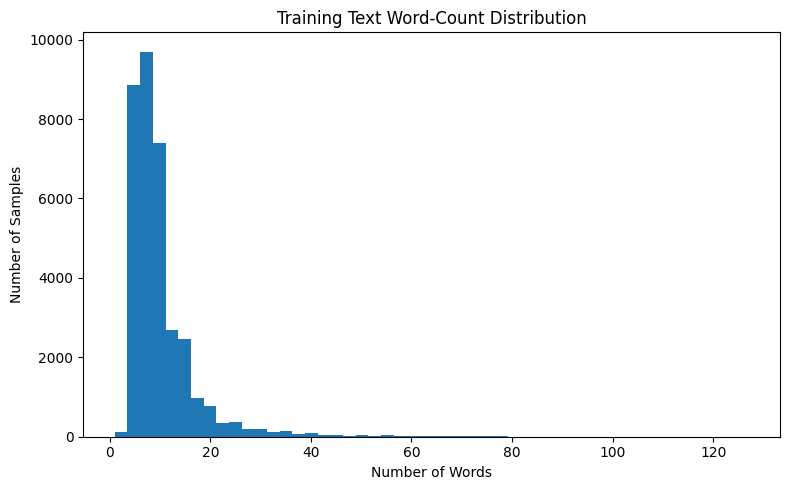

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(train_df["word_count"], bins=50)
plt.title("Training Text Word-Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

## Word Count by Class

Compares the word-count distribution across offensive-language categories to check whether comment length correlates with class.

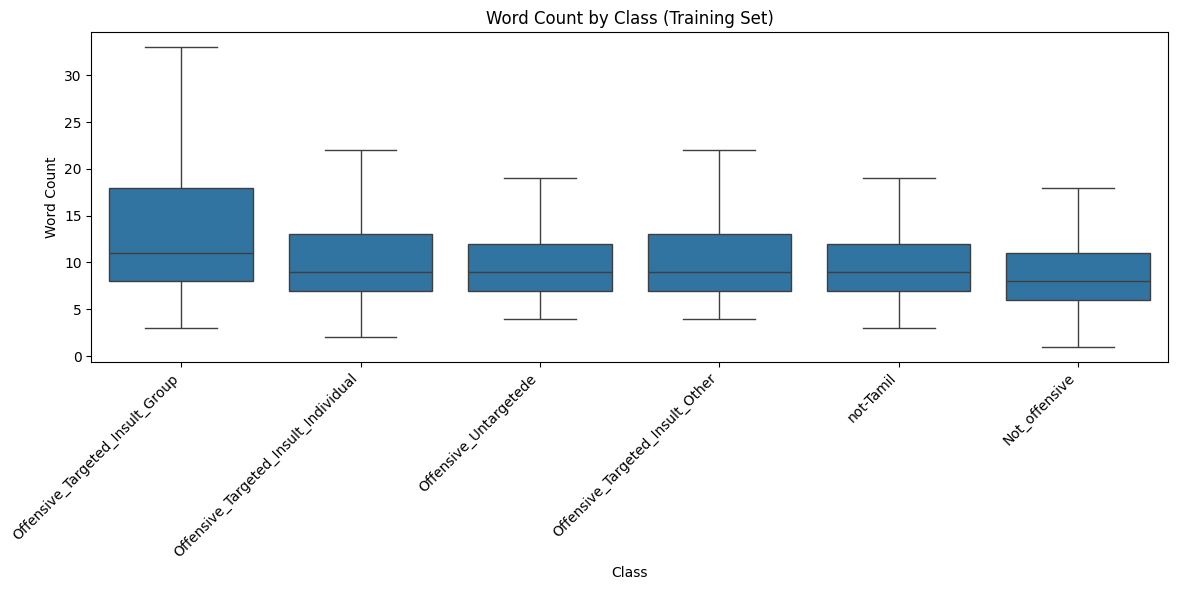

In [24]:
plt.figure(figsize=(12, 6))
order = train_df.groupby("label")["word_count"].median().sort_values(ascending=False).index
sns.boxplot(data=train_df, x="label", y="word_count", order=order, showfliers=False)
plt.title("Word Count by Class (Training Set)")
plt.xlabel("Class")
plt.ylabel("Word Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 17. Visualize Class Distribution

Plots the training-set class distribution to assess class imbalance.

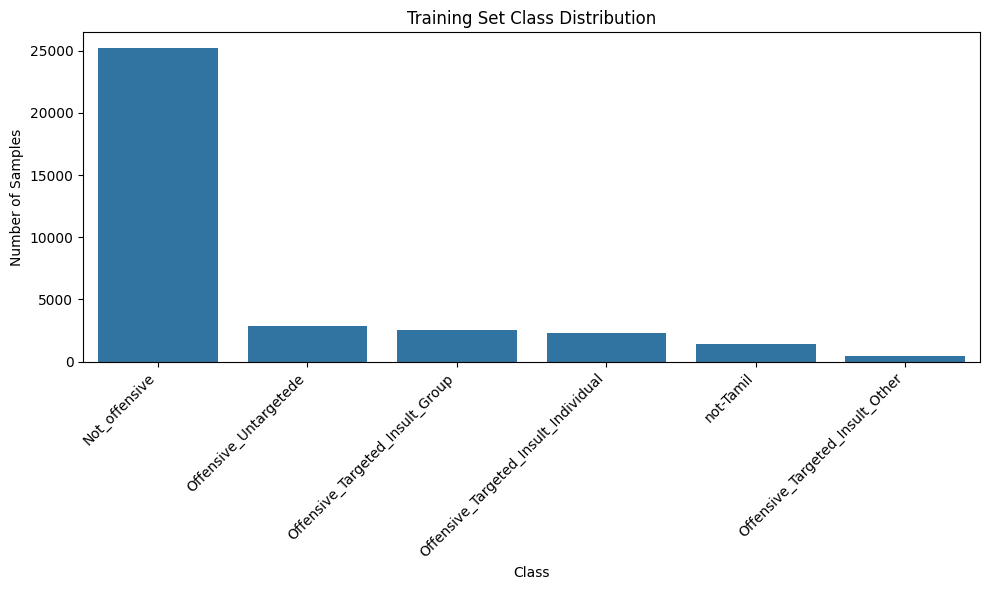

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x="label", order=train_df["label"].value_counts().index)
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 18. Class Distribution in Percentage

Expresses the training-set class distribution as percentages to quantify class imbalance.

In [26]:
class_distribution = train_df["label"].value_counts(normalize=True).mul(100).round(2)
display(class_distribution.to_frame("Percentage"))

,Percentage
label,
Not_offensive,72.25
Offensive_Untargetede,8.29
Offensive_Targeted_Insult_Group,7.31
Offensive_Targeted_Insult_Individual,6.70
not-Tamil,4.15
Offensive_Targeted_Insult_Other,1.30


## Class Distribution Across Official Splits

Compares the per-class percentage distribution across the train, development, and test splits to confirm the splits are consistently balanced.

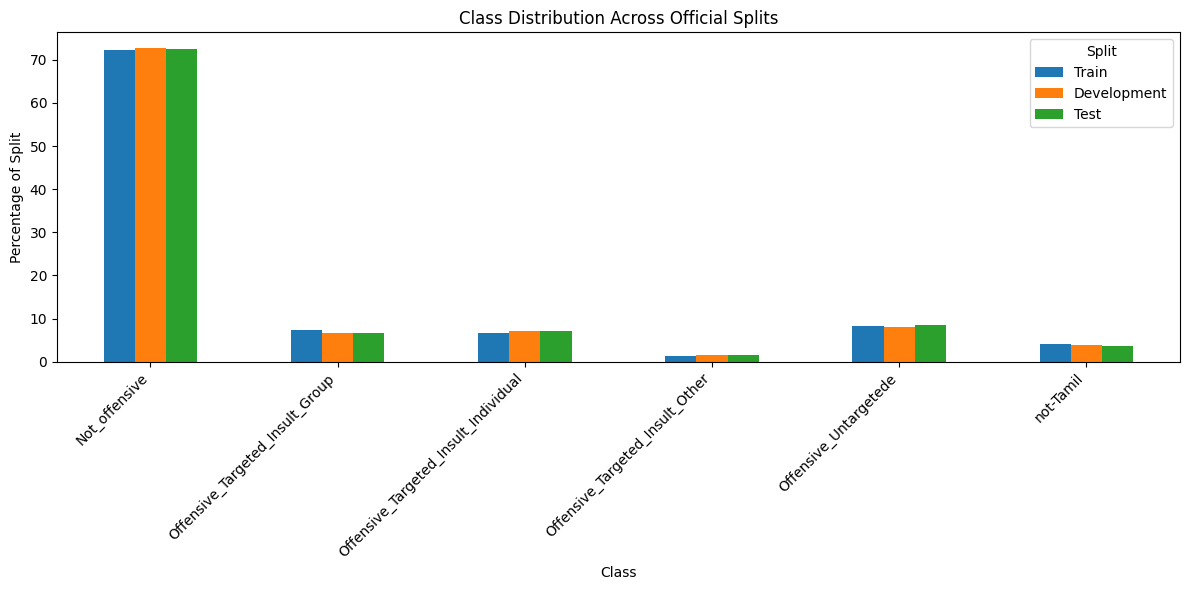

In [27]:
split_distribution = pd.DataFrame(
    {
        "Train": train_df["label"].value_counts(normalize=True).mul(100),
        "Development": dev_df["label"].value_counts(normalize=True).mul(100),
        "Test": test_df["label"].value_counts(normalize=True).mul(100),
    }
).fillna(0)
split_distribution.plot(kind="bar", figsize=(12, 6))
plt.title("Class Distribution Across Official Splits")
plt.xlabel("Class")
plt.ylabel("Percentage of Split")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

## 19. Inspect Representative Samples

Manually inspects sample comments from each class to observe code-mixing patterns and offensive expressions.

In [28]:
for label in all_labels:
    print("\n" + "=" * 70)
    print("CLASS:", label)
    print("=" * 70)
    samples = train_df[train_df["label"] == label]["text"].sample(
        min(5, len(train_df[train_df["label"] == label])), random_state=SEED
    )
    for text in samples:
        print("-", text)


CLASS: Not_offensive
- Ithu yethu maathiri illama puthu maathiyaala irukku
- மதுரை மாவட்டம் அனைத்து தேவர் சமுதாயம் படம் வெற்றி பெரும் வாழ்த்துகள்
- Thala Ajith oda acting skills ah paathu satisfied aanavanga like podunga. Class act Thala !!!!
- Sivakarthikeyan nee actora Mattum illa   Producera  atha vida bayangarama Kalakarada...Really proud of u...Well done...
- Marana MASS thalaivaa... Yengal Nadippin Nayagan #SURIYA#HAPPY

CLASS: Offensive_Targeted_Insult_Group
- இந்த படம் பள்ளர்களுக்கு சரியான சாட்டை அடி...
- mokka trailer semma joke name bhairava oh! hi chellam bhairavi
- Thu tariler ah ithu jathi naikalin attuliyan ha ha. Comedy peasunga manaketta jathikalai vacgitu savungada
- Politicians naala than namma naadae ipdi iruku... avanga than yarayum olunga vela paaka vidala.. including police..  suppose nalla thought oda yaarachum politics ku vanthaal.. onnu oda solluvanga... suppose odalana.. odukki ukkaara vechiruvanga... avanga apdi irukra varaikum... (nengalae yosichikonga).
- 

## 20. Data Cleaning

Applies lightweight cleaning (removing missing rows, stripping and normalizing whitespace) while preserving punctuation and code-mixed text.

In [29]:
import re

def basic_clean_text(text):
    text = str(text)

    # Remove carriage returns, tabs and newlines
    text = re.sub(r"[\r\n\t]+", " ", text)

    # Normalize Unicode whitespace
    text = re.sub(r"\s+", " ", text)

    # Reduce repeated punctuation
    # !!!!!!!! → !!!
    # ???????? → ???
    # ........ → ...
    text = re.sub(r"!{3,}", "!!!", text)
    text = re.sub(r"\?{3,}", "???", text)
    text = re.sub(r"\.{4,}", "...", text)

    # Reduce repeated punctuation combinations
    # !?!?!?!?! → !?!
    text = re.sub(r"([!?])\1{3,}", r"\1\1\1", text)

    # Remove spaces before punctuation
    # "hello !" → "hello!"
    text = re.sub(r"\s+([!?.,;:])", r"\1", text)

    # Remove excessive spaces again after cleaning
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def clean_dataframe(data):
    data = data.dropna(subset=["text", "label"]).copy()

    data["text"] = data["text"].astype(str)

    data["text"] = data["text"].apply(basic_clean_text)

    # Remove empty texts
    data = data[data["text"].str.strip() != ""].copy()

    return data.reset_index(drop=True)


train_df = clean_dataframe(train_df)
dev_df = clean_dataframe(dev_df)
test_df = clean_dataframe(test_df)

print("Train:", train_df.shape)
print("Dev  :", dev_df.shape)
print("Test :", test_df.shape)

Train: (34898, 4)
Dev  : (4380, 4)
Test : (4385, 4)


## 21. Prepare Input and Target Variables


In [30]:
X_train = train_df["text"]
y_train = train_df["label"]
X_dev = dev_df["text"]
y_dev = dev_df["label"]
X_test = test_df["text"]
y_test = test_df["label"]
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_dev:", X_dev.shape)
print("y_dev:", y_dev.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (34898,)
y_train: (34898,)
X_dev: (4380,)
y_dev: (4380,)
X_test: (4385,)
y_test: (4385,)


## 22. TF-IDF Feature Extraction

Fits a unigram+bigram TF-IDF vectorizer on the training data only, then transforms the development and test sets to avoid leakage.

In [31]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_dev_tfidf = tfidf_vectorizer.transform(X_dev)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF dev shape     :", X_dev_tfidf.shape)
print("TF-IDF test shape    :", X_test_tfidf.shape)

TF-IDF training shape: (34898, 41365)
TF-IDF dev shape     : (4380, 41365)
TF-IDF test shape    : (4385, 41365)


## 23. Inspect the TF-IDF Vocabulary

Reports the size of the learned TF-IDF vocabulary and samples a subset of the feature names.

In [32]:
feature_names = tfidf_vectorizer.get_feature_names_out()
print("Number of TF-IDF features:", len(feature_names))
print("\nFirst 50 features:")
print(feature_names[:50])

Number of TF-IDF features: 41365

First 50 features:
['00' '00 11' '00 19' '00 23' '00 26' '00 39' '00 44' '00 48' '00 57'
 '00 goosebumps' '00 மண' '000' '000 வயத' '01' '01 05' '01 14' '01 38'
 '01 min' '01 naan' '02' '03' '04' '05' '05 jayasudha' '05 marana' '05 to'
 '06' '06 str' '07' '08' '08 dsp' '08 la' '08 semma' '09' '10' '10 000'
 '10 2019' '10 30' '10 jai' '10 ku' '10 la' '10 million' '10 millions'
 '10 minutes' '10 padam' '10 sc' '10 thadava' '10 thala' '10 time'
 '10 times']


## 24. Classical Baseline Models

Two classical classifiers are considered using the same TF-IDF unigram+bigrams representation:
- Logistic Regression
- Linear SVM

Both models are trained on the official training set and tuned using the development set. Macro F1 is used as the primary selection metric because the six classes are imbalanced.

## 25. Tune Logistic Regression on the Development Set

Trains a Logistic Regression classifier for each candidate `C` on the training set and evaluates it on the development set.

In [33]:
C_values = [0.01, 0.1, 1, 10, 100]

best_logreg_model = None
best_C_logreg = None
best_macro_f1_logreg = -1

logreg_dev_results = []

for C in C_values:

    model = LogisticRegression(C=C, max_iter=1000, random_state=SEED)
    model.fit(X_train_tfidf, y_train)

    y_dev_pred = model.predict(X_dev_tfidf)

    macro_f1 = f1_score(y_dev, y_dev_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_dev, y_dev_pred, average="weighted", zero_division=0)

    logreg_dev_results.append({
        "C": C,
        "Dev_Accuracy": accuracy_score(y_dev, y_dev_pred),
        "Dev_Macro_F1": macro_f1,
        "Dev_Weighted_F1": weighted_f1
    })

    if macro_f1 > best_macro_f1_logreg:
        best_macro_f1_logreg = macro_f1
        best_C_logreg = C
        best_logreg_model = model

logreg_dev_results_df = pd.DataFrame(logreg_dev_results)

display(logreg_dev_results_df.round(4))

print(f"Best Logistic Regression C: {best_C_logreg}")
print(f"Best Logistic Regression Dev Macro F1: {best_macro_f1_logreg:.4f}")

,C,Dev_Accuracy,Dev_Macro_F1,Dev_Weighted_F1
0,0.01,0.7274,0.1404,0.6126
1,0.10,0.7352,0.2030,0.6323
2,1.00,0.7726,0.3957,0.7227
3,10.00,0.7671,0.4327,0.7418
4,100.00,0.7505,0.4320,0.7344


Best Logistic Regression C: 10
Best Logistic Regression Dev Macro F1: 0.4327


## 26. Tune Linear SVM on the Development Set

Trains a `LinearSVC` classifier for each candidate `C` on the training set and evaluates it on the development set

In [34]:
from sklearn.svm import LinearSVC

best_svm_model = None
best_C_svm = None
best_macro_f1_svm = -1

svm_dev_results = []

for C in C_values:

    model = LinearSVC(C=C, random_state=SEED)
    model.fit(X_train_tfidf, y_train)

    y_dev_pred = model.predict(X_dev_tfidf)

    macro_f1 = f1_score(y_dev, y_dev_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_dev, y_dev_pred, average="weighted", zero_division=0)

    svm_dev_results.append({
        "C": C,
        "Dev_Accuracy": accuracy_score(y_dev, y_dev_pred),
        "Dev_Macro_F1": macro_f1,
        "Dev_Weighted_F1": weighted_f1
    })

    if macro_f1 > best_macro_f1_svm:
        best_macro_f1_svm = macro_f1
        best_C_svm = C
        best_svm_model = model

svm_dev_results_df = pd.DataFrame(svm_dev_results)

display(svm_dev_results_df.round(4))

print(f"Best Linear SVM C: {best_C_svm}")
print(f"Best Linear SVM Dev Macro F1: {best_macro_f1_svm:.4f}")

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,C,Dev_Accuracy,Dev_Macro_F1,Dev_Weighted_F1
0,0.01,0.7324,0.1809,0.6245
1,0.10,0.7703,0.3703,0.7095
2,1.00,0.7687,0.4319,0.7409
3,10.00,0.7368,0.4210,0.7272
4,100.00,0.7176,0.4080,0.7136


Best Linear SVM C: 1
Best Linear SVM Dev Macro F1: 0.4319


## 27. Compare Tuned Candidates on the Development Set

Compares the best Logistic Regression and Linear SVM configurations using development Macro F1 as the classes are imbalanced

In [35]:
print("Selecting based on Macro F1 Score")
print("-"*60)
print("Logistic Regression Macro F1:", round(best_macro_f1_logreg, 4))
print("Linear SVM Macro F1:", round(best_macro_f1_svm, 4))

if best_macro_f1_logreg>best_macro_f1_svm:
    best_model_name="Logistic Regression"
    best_C=best_C_logreg
    best_dev_macro_f1=best_macro_f1_logreg
    final_baseline_model=best_logreg_model
else:
    best_model_name="Linear SVM"
    best_C=best_C_svm
    best_dev_macro_f1=best_macro_f1_svm
    final_baseline_model=best_svm_model

print("-"*60)
print(f"Selected baseline: {best_model_name} (C={best_C_logreg})")

Selecting based on Macro F1 Score
------------------------------------------------------------
Logistic Regression Macro F1: 0.4327
Linear SVM Macro F1: 0.4319
------------------------------------------------------------
Selected baseline: Logistic Regression (C=10)


## 28. Prediction using the final Baseline Model


In [36]:
y_test_pred=final_baseline_model.predict(X_test_tfidf)

## 29. Final Test Set Evaluation

In [37]:
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision_macro = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
test_recall_macro = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
test_f1_macro = f1_score(y_test, y_test_pred, average="macro", zero_division=0)
test_precision_weighted = precision_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_recall_weighted = recall_score(y_test, y_test_pred, average="weighted", zero_division=0)
test_f1_weighted = f1_score(y_test, y_test_pred, average="weighted", zero_division=0)

print(f"Final Test Results ({best_model_name})")
print("-" * (20 + len(best_model_name)))
print(f"Accuracy           : {test_accuracy:.4f}")
print(f"Macro Precision    : {test_precision_macro:.4f}")
print(f"Macro Recall       : {test_recall_macro:.4f}")
print(f"Macro F1           : {test_f1_macro:.4f}")
print(f"Weighted Precision : {test_precision_weighted:.4f}")
print(f"Weighted Recall    : {test_recall_weighted:.4f}")
print(f"Weighted F1        : {test_f1_weighted:.4f}")

Final Test Results (Logistic Regression)
---------------------------------------
Accuracy           : 0.7683
Macro Precision    : 0.5448
Macro Recall       : 0.4031
Macro F1           : 0.4407
Weighted Precision : 0.7302
Weighted Recall    : 0.7683
Weighted F1        : 0.7402


## 30. Classification Report

Generates the per-class classification report for the selected final baseline on the test set.

In [38]:
report = classification_report(y_test, y_test_pred, zero_division=0)
print(report)

                                      precision    recall  f1-score   support

                       Not_offensive       0.83      0.94      0.88      3184
     Offensive_Targeted_Insult_Group       0.36      0.25      0.30       288
Offensive_Targeted_Insult_Individual       0.45      0.24      0.32       315
     Offensive_Targeted_Insult_Other       0.33      0.03      0.05        71
               Offensive_Untargetede       0.43      0.30      0.35       368
                           not-Tamil       0.87      0.65      0.74       159

                            accuracy                           0.77      4385
                           macro avg       0.54      0.40      0.44      4385
                        weighted avg       0.73      0.77      0.74      4385



## 31. Confusion Matrix


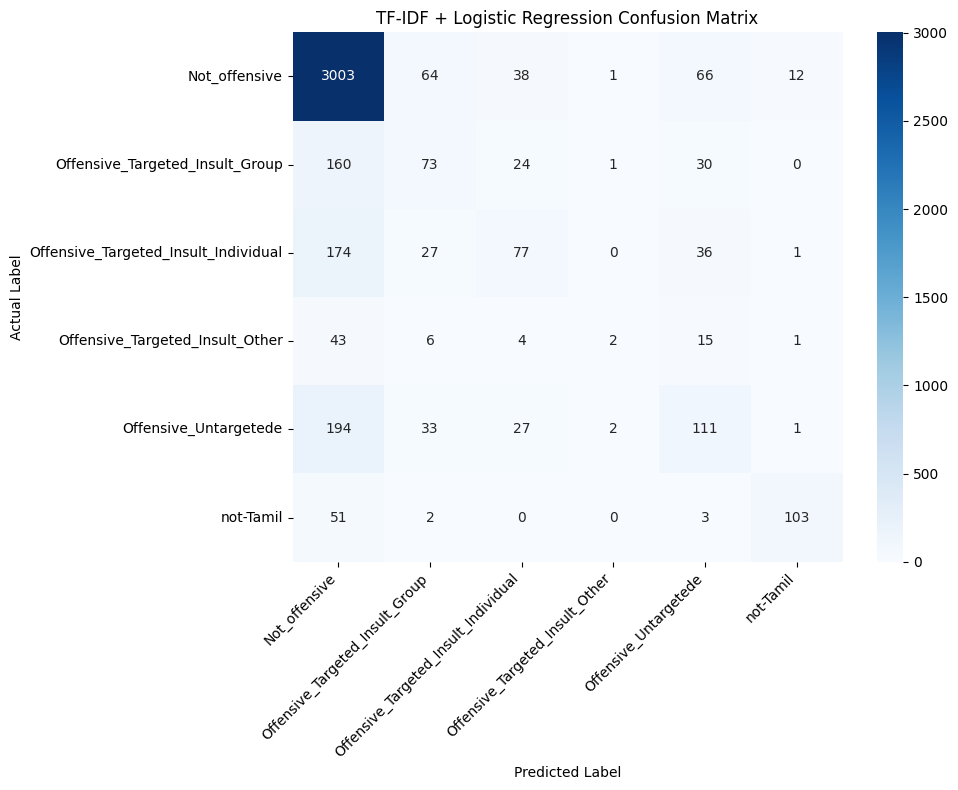

In [39]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"TF-IDF + {best_model_name} Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 32. Normalized Confusion Matrix

Generates the row-normalized test confusion matrix for the selected final baseline.

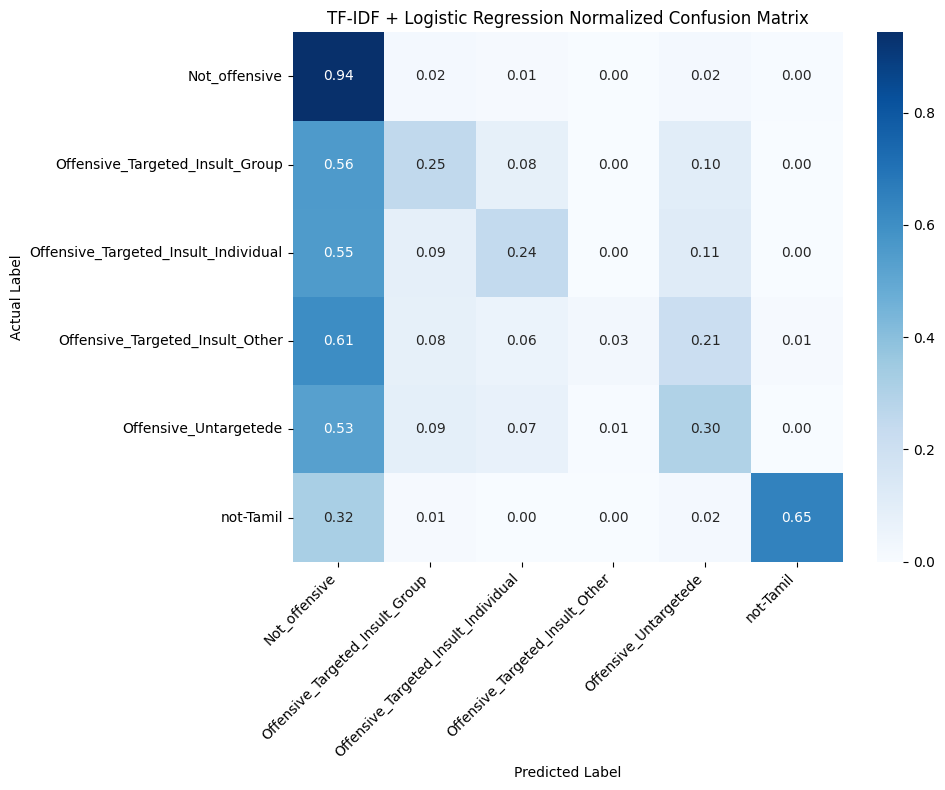

In [40]:
cm_normalized = confusion_matrix(y_test, y_test_pred, labels=labels, normalize="true")
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title(f"TF-IDF + {best_model_name} Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 33. Final Baseline Performance Summary


In [41]:
baseline_results = pd.DataFrame(
    {
        "Model": [best_model_name],
        "Best C": [best_C],
        "Accuracy": [test_accuracy],
        "Macro Precision": [test_precision_macro],
        "Macro Recall": [test_recall_macro],
        "Macro F1": [test_f1_macro],
        "Weighted F1": [test_f1_weighted],
    }
)
display(baseline_results.round(4))

,Model,Best C,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression,10,0.7683,0.5448,0.4031,0.4407,0.7402


## 34. Feature Importance / Model Interpretation

Shows the TF-IDF terms with the strongest coefficients per class for the selected final baseline.

/tmp/ipykernel_1081/3137761588.py:14: UserWarning: Glyph 2986 (\N{TAMIL LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1081/3137761588.py:14: UserWarning: Matplotlib currently does not support Tamil natively.
  plt.tight_layout()
/tmp/ipykernel_1081/3137761588.py:14: UserWarning: Glyph 2975 (\N{TAMIL LETTER TTA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1081/3137761588.py:14: UserWarning: Glyph 2990 (\N{TAMIL LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1081/3137761588.py:14: UserWarning: Glyph 2992 (\N{TAMIL LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1081/3137761588.py:14: UserWarning: Glyph 2997 (\N{TAMIL LETTER VA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1081/3137761588.py:14: UserWarning: Glyph 2995 (\N{TAMIL LETTER LLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1081/3137761588.py:14: 

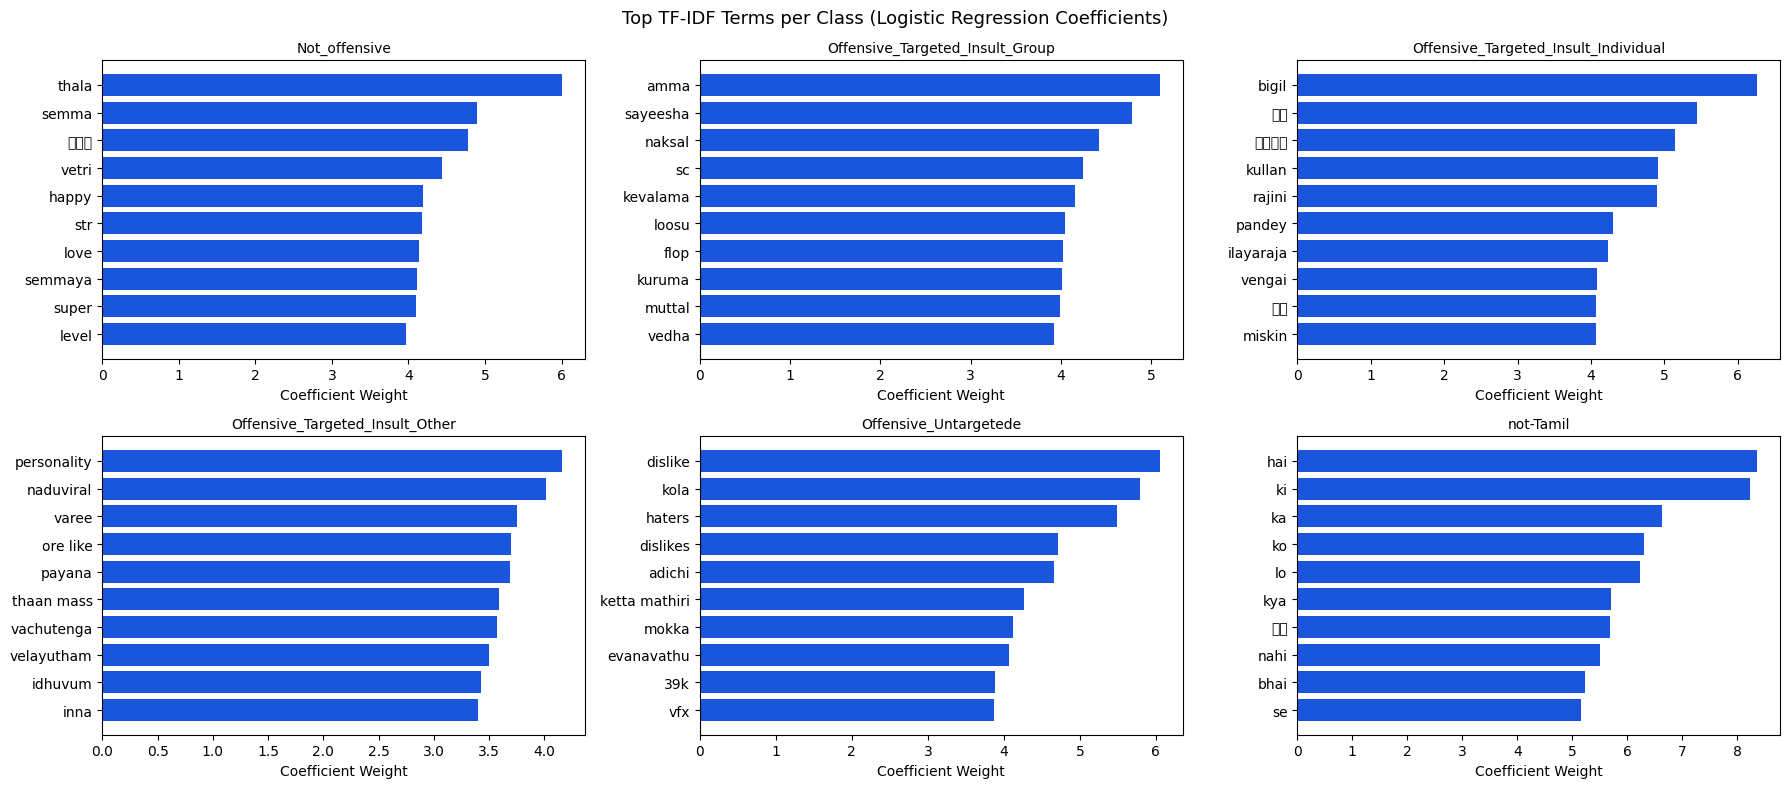

In [42]:
feature_names_arr = tfidf_vectorizer.get_feature_names_out()
n_classes = len(final_baseline_model.classes_)
fig, axes = plt.subplots(2, (n_classes + 1) // 2, figsize=(18, 8))
axes = axes.flatten()
for idx, class_label in enumerate(final_baseline_model.classes_):
    coefficients = final_baseline_model.coef_[idx]
    top_indices = np.argsort(coefficients)[-10:]
    axes[idx].barh(feature_names_arr[top_indices], coefficients[top_indices], color="#1a56db")
    axes[idx].set_title(class_label, fontsize=10)
    axes[idx].set_xlabel("Coefficient Weight")
for idx in range(n_classes, len(axes)):
    axes[idx].axis("off")
plt.suptitle(f"Top TF-IDF Terms per Class ({best_model_name} Coefficients)", fontsize=13)
plt.tight_layout()
plt.show()

## 35. Test Error Analysis

Identifies misclassified test samples for the selected final baseline.

In [43]:
error_analysis_df = pd.DataFrame(
    {"text": X_test.values, "actual_label": y_test.values, "predicted_label": y_test_pred}
)
errors = error_analysis_df[error_analysis_df["actual_label"] != error_analysis_df["predicted_label"]].copy()
print("Total test samples:", len(error_analysis_df))
print("Misclassified samples:", len(errors))
display(errors.head(20))

Total test samples: 4385
Misclassified samples: 1016


,text,actual_label,predicted_label
4,suma kaththaatha da sound over a pooda kudaathu pa s3 1 month oda stop aakidum then bairavaa da aaddchi than kaththi kaththi thondaiya kilikatha pa,Offensive_Untargetede,Offensive_Targeted_Insult_Individual
5,ஆனவக் கொலைகள் நடக்காவிடில்...நம் அடையாளம் அளிக்கப்படும்... இயக்குனருக்கு வாழ்த்துக்கள்...தமிழ்நாடு முத்தரையர்கள்,Offensive_Targeted_Insult_Group,Not_offensive
8,Power ranger megazord niyabagam vantha hit like,Offensive_Untargetede,Not_offensive
13,0:28 Shaktimaan Parle-G Biscuit SaptuNaanum sinna vayasula jump panni parakka try pannirukken 90's Pasanga Da 🤣,Offensive_Untargetede,Not_offensive
20,எவனுக்கும் அடங்க மாட்டோம்... எவளுக்கும் மயங்க மாட்டோம்🤙... # நாடக காதல் # கும்பல்களை வேரோடு அழிக்க வந்த # திரௌபதி படத்திற்கு.. தேவேந்திர குல வேளாளர் சார்பாக வாழ்த்துக்கள்.,Offensive_Targeted_Insult_Group,Not_offensive
21,Movie yachum nailla eruka nu papom,Offensive_Untargetede,Not_offensive
22,nice aana teaser starting laa vandha dialogue mgr sir engaveetu Pillai la padina naan anai etal ooda middle lines laa...,Offensive_Targeted_Insult_Other,Not_offensive
24,Yannada trailer idhu yadho oruthava family la nadakkura kadhaiya yaduthu vachirukka,Offensive_Untargetede,Not_offensive
27,Dai unmaiyanumea marana kattu katuvega pola,Offensive_Untargetede,Not_offensive
35,🤣🤣🤣 video ku dislike pottavangalam vanthu Inka oru like ah thatti vitutu ponga,Offensive_Targeted_Insult_Other,Offensive_Untargetede


## 36. Prediction Confidence

For Logistic Regression, reports predicted-class probabilities as a confidence score. `LinearSVC` does not expose `predict_proba` by default, so when it is the selected model its raw `decision_function` margin is reported instead and explicitly labeled a decision score, not a probability.

In [44]:
pd.set_option("display.max_colwidth", None)
if best_model_name == "Logistic Regression":
    test_probabilities = final_baseline_model.predict_proba(X_test_tfidf)
    confidence = np.max(test_probabilities, axis=1)
    error_analysis_df["confidence"] = confidence
    errors = error_analysis_df[error_analysis_df["actual_label"] != error_analysis_df["predicted_label"]].copy()
    print("confidence = predicted-class probability (Logistic Regression).")
    display(errors.sort_values("confidence", ascending=True).head(20))
else:
    decision_scores = final_baseline_model.decision_function(X_test_tfidf)
    decision_score = np.max(decision_scores, axis=1)
    error_analysis_df["decision_score"] = decision_score
    errors = error_analysis_df[error_analysis_df["actual_label"] != error_analysis_df["predicted_label"]].copy()
    print("decision_score = raw LinearSVC decision_function margin, NOT a probability.")
    display(errors.sort_values("decision_score", ascending=True).head(20))

confidence = predicted-class probability (Logistic Regression).


,text,actual_label,predicted_label,confidence
80,Poga dai sarkar tha best NGK waste,Offensive_Targeted_Insult_Group,Offensive_Targeted_Insult_Individual,0.267428
2603,Motha padathayum trailer la pota... Padathla Ena da irkum?!,Offensive_Targeted_Insult_Group,Offensive_Targeted_Insult_Individual,0.276446
3059,Pakarathuku Chinna paiyan maathiriya??? poi sonnalum oru nayam venamada!!!,Offensive_Untargetede,Offensive_Targeted_Insult_Individual,0.282707
2988,Who gave dislike is ajith fan,Not_offensive,Offensive_Untargetede,0.293009
3268,Entha padam velangathu da nasama poidum da,Offensive_Targeted_Insult_Individual,Not_offensive,0.298306
4117,Ena da old jai Shankar movie mathiri iruku,Offensive_Targeted_Insult_Individual,Offensive_Targeted_Insult_Group,0.305412
2152,Enakku bgm pudikkala waste bgm old bgm,Offensive_Untargetede,Offensive_Targeted_Insult_Group,0.306901
43,"Vjs, udanbu veengittu varuthu, 45 vayadhu mathiri theriyuthu,. Nallave ille, middle age RO ok a chose pannu",Not_offensive,Offensive_Targeted_Insult_Individual,0.310034
1599,Music engayo kae ta madhari irukae,Offensive_Untargetede,Offensive_Targeted_Insult_Group,0.311847
3440,Padathoda cg pathi pesunavankaluku sariyana adi,Offensive_Untargetede,Offensive_Targeted_Insult_Individual,0.314286


## 37. Save Test Predictions

Saves the selected final baseline's test predictions and misclassified samples.

In [45]:
os.makedirs("results", exist_ok=True)
error_analysis_df.to_csv("results/baseline_test_predictions.csv", index=False)
errors.to_csv("results/baseline_errors.csv", index=False)
print("Prediction files saved.")

Prediction files saved.


## 38. Save the Selected Baseline Model

Persists the TF-IDF vectorizer and the selected final baseline model for later inference.

In [46]:
os.makedirs("models", exist_ok=True)
joblib.dump(tfidf_vectorizer, "models/tfidf_vectorizer.pkl")
joblib.dump(final_baseline_model, "models/best_tuned_baseline.pkl")
print("TF-IDF vectorizer saved.")
print(f"Selected baseline model ({best_model_name}) saved.")

TF-IDF vectorizer saved.
Selected baseline model (Logistic Regression) saved.


## 39. Save Experiment Configuration

Records the experiment's configuration, including both tuned candidates' development results and the final selection, for reproducibility.

In [47]:
experiment_config = {
    "random_seed": SEED,
    "train_samples": len(train_df),
    "dev_samples": len(dev_df),
    "test_samples": len(test_df),
    "tfidf_ngram_range": "(1, 2)",
    "tfidf_min_df": 2,
    "tfidf_max_df": 0.95,
    "tfidf_sublinear_tf": True,
    "selected_model": best_model_name,
    "selected_C": best_C,
    "selected_dev_macro_f1": best_dev_macro_f1,
    "logreg_best_C": best_C_logreg,
    "logreg_best_dev_macro_f1": best_macro_f1_logreg,
    "svm_best_C": best_C_svm,
    "svm_best_dev_macro_f1": best_macro_f1_svm,
}
config_df = pd.DataFrame(list(experiment_config.items()), columns=["Parameter", "Value"])
display(config_df)
os.makedirs("results", exist_ok=True)
config_df.to_csv("results/baseline_experiment_config.csv", index=False)

,Parameter,Value
0,random_seed,42
1,train_samples,34898
2,dev_samples,4380
3,test_samples,4385
4,tfidf_ngram_range,"(1, 2)"
5,tfidf_min_df,2
6,tfidf_max_df,0.95
7,tfidf_sublinear_tf,True
8,selected_model,Logistic Regression
9,selected_C,10


## 40. Save Cleaned Dataset Splits

Saves the cleaned train, development, and test splits so the same data can be used to train the Transformer model.

In [48]:
os.makedirs("data/processed", exist_ok=True)
train_df.to_csv("data/processed/train.csv", index=False)
dev_df.to_csv("data/processed/dev.csv", index=False)
test_df.to_csv("data/processed/test.csv", index=False)
print("Processed datasets saved.")

Processed datasets saved.


## 41. Final Summary


In [49]:
print("=" * 60)
print("BASELINE PIPELINE COMPLETED")
print("=" * 60)
print("\nDataset:")
print(f"Train samples: {len(train_df)}")
print(f"Dev samples  : {len(dev_df)}")
print(f"Test samples : {len(test_df)}")
print("\nNumber of classes:", len(all_labels))
print(f"\nSelected Baseline: TF-IDF + {best_model_name}")
print(f"Selected C: {best_C}")
print(f"Dev Macro F1 (selection metric): {best_dev_macro_f1:.4f}")
print("\nFinal Test Performance:")
print(f"Accuracy           : {test_accuracy:.4f}")
print(f"Macro Precision    : {test_precision_macro:.4f}")
print(f"Macro Recall       : {test_recall_macro:.4f}")
print(f"Macro F1           : {test_f1_macro:.4f}")
print(f"Weighted F1        : {test_f1_weighted:.4f}")
print("\nSaved models:")
print("models/tfidf_vectorizer.pkl")
print("models/best_tuned_baseline.pkl")
print("\nSaved datasets:")
print("data/processed/train.csv")
print("data/processed/dev.csv")
print("data/processed/test.csv")
print("\nSaved results:")
print("results/baseline_test_predictions.csv")
print("results/baseline_errors.csv")
print("results/baseline_experiment_config.csv")

BASELINE PIPELINE COMPLETED

Dataset:
Train samples: 34898
Dev samples  : 4380
Test samples : 4385

Number of classes: 6

Selected Baseline: TF-IDF + Logistic Regression
Selected C: 10
Dev Macro F1 (selection metric): 0.4327

Final Test Performance:
Accuracy           : 0.7683
Macro Precision    : 0.5448
Macro Recall       : 0.4031
Macro F1           : 0.4407
Weighted F1        : 0.7402

Saved models:
models/tfidf_vectorizer.pkl
models/best_tuned_baseline.pkl

Saved datasets:
data/processed/train.csv
data/processed/dev.csv
data/processed/test.csv

Saved results:
results/baseline_test_predictions.csv
results/baseline_errors.csv
results/baseline_experiment_config.csv


# 42. Transformer Model Research

The objective is to identify a suitable pretrained Transformer for Tamil-English code-mixed offensive-language classification.

1. IndicBERT
2. MuRIL
3. XLM-R


| Study                           | Dataset/Task                             | Models                             | Key observation                                                         |
| ------------------------------- | ---------------------------------------- | ---------------------------------- | ----------------------------------------------------------------------- |
| NLP-CUET, 2021                  | Dravidian code-mixed offensive detection | mBERT, IndicBERT, XLM-R            | XLM-R performed strongly for Tamil                                      |
| Tamil offensive detection study | Tamil offensive content                  | BERT, XLM-R, IndicBERT, MuRIL etc. | MuRIL achieved strong results in their setup                            |
| Adapter study                   | Tamil-English offensive content          | mBERT, MuRIL, XLM-R                | Transformer approaches outperformed traditional ML in their experiments |
| DravidianLangTech 2024          | Tamil-English offensive detection        | SetFit + comparisons               | Sentence-transfer approaches investigated                               |
| NLP4DH 2025                     | Tamil-English code-mixed sentiment       | XLM-R, mT5, IndicBERT, RemBERT     | Highlights code-mixed linguistic challenges                             |

### Selected Transformer

XLM-RoBERTa Base
Model: xlm-roberta-base

Reasons:
1. It supports multilingual text including Tamil and English.
2. It has been evaluated on Dravidian code-mixed text.
3. Previous work has reported strong performance for Tamil
   code-mixed offensive-language detection.
4. It provides a suitable comparison against the TF-IDF
   classical baseline.


## 43. Transformer Environment Setup

In [50]:
# Install Transformer dependencies

%pip install -U transformers datasets accelerate evaluate scikit-learn

# 44. Import Libraries

In [51]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [52]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)
print("Device:", "CUDA" if torch.cuda.is_available() else "CPU")

Random seed: 42
Device: CUDA


# 45. Load Processed Dataset

In [53]:
TRAIN_PATH = "data/processed/train.csv"
DEV_PATH = "data/processed/dev.csv"
TEST_PATH = "data/processed/test.csv"

train_df = pd.read_csv(TRAIN_PATH)
dev_df = pd.read_csv(DEV_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Dev shape:", dev_df.shape)
print("Test shape:", test_df.shape)

Train shape: (34898, 4)
Dev shape: (4380, 4)
Test shape: (4385, 4)


In [54]:
print("Training labels:")
print(train_df["label"].value_counts())

Training labels:
label
Not_offensive                           25215
Offensive_Untargetede                    2894
Offensive_Targeted_Insult_Group          2550
Offensive_Targeted_Insult_Individual     2338
not-Tamil                                1447
Offensive_Targeted_Insult_Other           454
Name: count, dtype: int64


# 46. Label Encoding

In [55]:
labels = sorted(train_df["label"].unique())

label2id = {
    label: i for i, label in enumerate(labels)
}

id2label = {
    i: label for label, i in label2id.items()
}

print("Label mapping:")
print(label2id)

Label mapping:
{'Not_offensive': 0, 'Offensive_Targeted_Insult_Group': 1, 'Offensive_Targeted_Insult_Individual': 2, 'Offensive_Targeted_Insult_Other': 3, 'Offensive_Untargetede': 4, 'not-Tamil': 5}


In [56]:
train_df["label_id"] = train_df["label"].map(label2id)
dev_df["label_id"] = dev_df["label"].map(label2id)
test_df["label_id"] = test_df["label"].map(label2id)

print(train_df[["text", "label", "label_id"]].head())

                                                                                  text  \
0                                                    movie vara level la Erika poguthu   
1                               I love Ajith Kumar Vivegam movie inki mjy bht achi lgi   
2                                            Padam nalla comedy padama irukum polaye..   
3  karthick subburaj anne... intha padam vetri adaya unagalukku ennudaya valthukkal...   
4                                    கவுண்டர் தேவர்.சார்பாக வெற்றி பெற வாழ்த்துக்கள் 🦁   

           label  label_id  
0  Not_offensive         0  
1      not-Tamil         5  
2  Not_offensive         0  
3  Not_offensive         0  
4  Not_offensive         0  


# 47. Load XLM-R Tokenizer

In [57]:
MODEL_NAME = "xlm-roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully.")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Tokenizer loaded successfully.


# 48. Tokenization

In [58]:
MAX_LENGTH = 128

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

In [59]:
# Convert Pandas → Hugging Face Dataset

from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["text", "label_id"]]
)

dev_dataset = Dataset.from_pandas(
    dev_df[["text", "label_id"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label_id"]]
)

print(train_dataset.column_names)

['text', 'label_id']


In [60]:
# Tokenize All Splits

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

dev_dataset = dev_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/34898 [00:00<?, ? examples/s]

Map:   0%|          | 0/4380 [00:00<?, ? examples/s]

Map:   0%|          | 0/4385 [00:00<?, ? examples/s]

In [61]:
# Rename Label Column
train_dataset = train_dataset.rename_column(
    "label_id", "labels"
)

dev_dataset = dev_dataset.rename_column(
    "label_id", "labels"
)

test_dataset = test_dataset.rename_column(
    "label_id", "labels"
)

In [62]:
# Remove Unnecessary Columns

train_dataset = train_dataset.remove_columns(["text"])
dev_dataset = dev_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

In [63]:
# Check Tokenization

print(train_dataset.column_names)

sample = train_dataset[0]

print("Input IDs:")
print(sample["input_ids"][:20])

print("\nAttention Mask:")
print(sample["attention_mask"][:20])

print("\nLabel:")
print(sample["labels"])

['labels', 'input_ids', 'attention_mask']
Input IDs:
[0, 14277, 2487, 17366, 21, 27303, 11, 126585, 1132, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Label:
0


# 49. Load XLM-R Classification Model

In [64]:
NUM_LABELS = len(labels)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
)

print("Model loaded.")
print("Number of labels:", NUM_LABELS)

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.
Number of labels: 6


# 50. Evaluation Metrics

In [65]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def compute_metrics(eval_pred):
    predictions, labels_true = eval_pred

    # Convert model logits to predicted class
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels_true, predictions)

    precision = precision_score(
        labels_true,
        predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        labels_true,
        predictions,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        labels_true,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# 51. Training Configuration

In [66]:
from transformers import TrainingArguments

TRANSFORMER_EPOCHS = 2
TRANSFORMER_BATCH_SIZE = 8
TRANSFORMER_LEARNING_RATE = 2e-5
TRANSFORMER_WEIGHT_DECAY = 0.01

training_args = TrainingArguments(
    output_dir="./models/xlmr_checkpoints",
    num_train_epochs=TRANSFORMER_EPOCHS,
    per_device_train_batch_size=TRANSFORMER_BATCH_SIZE,
    per_device_eval_batch_size=TRANSFORMER_BATCH_SIZE,
    learning_rate=TRANSFORMER_LEARNING_RATE,
    weight_decay=TRANSFORMER_WEIGHT_DECAY,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="epoch",
    report_to="none",
    seed=42
)

print("Model:", MODEL_NAME)
print("Epochs:", TRANSFORMER_EPOCHS)
print("Batch size:", TRANSFORMER_BATCH_SIZE)
print("Learning rate:", TRANSFORMER_LEARNING_RATE)
print("Weight decay:", TRANSFORMER_WEIGHT_DECAY)
print("Maximum sequence length:", MAX_LENGTH)

if torch.cuda.is_available():
    print("Device: GPU")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Device: CPU")

Model: xlm-roberta-base
Epochs: 2
Batch size: 8
Learning rate: 2e-05
Weight decay: 0.01
Maximum sequence length: 128
Device: GPU
GPU: Tesla T4


# 52. Create Trainer

In [67]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


# 53. Train the Transformer

In [68]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.827858,0.732675,0.740639,0.434079,0.417398,0.401382
2,0.679180,0.684361,0.772374,0.469677,0.405042,0.419151


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

# 54. Validate on Development Set

In [69]:
dev_results = trainer.evaluate(
    eval_dataset=dev_dataset
)

print(dev_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.679180,0.684361,2,0.772374,0.469677,0.405042,0.419151


{'eval_loss': 0.684361457824707, 'eval_accuracy': 0.7723744292237443, 'eval_precision': 0.46967651520652026, 'eval_recall': 0.40504245406566497, 'eval_f1': 0.4191505611763134}


# 55. Final Test Evaluation

In [70]:
test_results = trainer.evaluate(
    eval_dataset=test_dataset
)

print("=" * 60)
print("FINAL XLM-R TEST RESULTS")
print("=" * 60)

print(f"Accuracy         : {test_results['eval_accuracy']:.4f}")
print(f"Macro Precision  : {test_results['eval_precision']:.4f}")
print(f"Macro Recall     : {test_results['eval_recall']:.4f}")
print(f"Macro F1         : {test_results['eval_f1']:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.679180,0.705091,2,0.764880,0.449194,0.384500,0.401483


FINAL XLM-R TEST RESULTS
Accuracy         : 0.7649
Macro Precision  : 0.4492
Macro Recall     : 0.3845
Macro F1         : 0.4015


# Hyperparameter Experiment

In [82]:
experiments = [
    {
        "Experiment": "Experiment 1",
        "Epochs": 2,
        "Batch Size": 8,
        "Learning Rate": 2e-5
    },
    {
        "Experiment": "Experiment 2",
        "Epochs": 3,
        "Batch Size": 8,
        "Learning Rate": 2e-5
    },
    {
        "Experiment": "Experiment 3",
        "Epochs": 2,
        "Batch Size": 8,
        "Learning Rate": 3e-5
    }
]

hyperparameter_results = []

for exp in experiments:

    print("\n" + "=" * 70)
    print(exp["Experiment"])
    print("=" * 70)

    print("Epochs       :", exp["Epochs"])
    print("Batch Size   :", exp["Batch Size"])
    print("Learning Rate:", exp["Learning Rate"])

    # Create a fresh XLM-R model
    experiment_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(labels),
        id2label=id2label,
        label2id=label2id
    )

    experiment_args = TrainingArguments(
        output_dir=f"./hyperparameter_results/{exp['Experiment']}",

        num_train_epochs=exp["Epochs"],

        per_device_train_batch_size=exp["Batch Size"],
        per_device_eval_batch_size=exp["Batch Size"],

        learning_rate=exp["Learning Rate"],
        weight_decay=0.01,

        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",

        report_to="none"
    )

    experiment_trainer = Trainer(
        model=experiment_model,
        args=experiment_args,

        train_dataset=train_dataset,
        eval_dataset=dev_dataset,

        processing_class=tokenizer,

        compute_metrics=compute_metrics
    )

    # Train
    experiment_trainer.train()

    # Evaluate
    experiment_result = experiment_trainer.evaluate()

    # Store results
    hyperparameter_results.append({
        "Experiment": exp["Experiment"],
        "Epochs": exp["Epochs"],
        "Batch Size": exp["Batch Size"],
        "Learning Rate": exp["Learning Rate"],
        "Accuracy": experiment_result["eval_accuracy"],
        "Precision": experiment_result["eval_precision"],
        "Recall": experiment_result["eval_recall"],
        "F1": experiment_result["eval_f1"]
    })


# Convert results to DataFrame
hyperparameter_results_df = pd.DataFrame(
    hyperparameter_results
)

print("\n")
print("=" * 70)
print("HYPERPARAMETER EXPERIMENT RESULTS")
print("=" * 70)

display(hyperparameter_results_df)


Experiment 1
Epochs       : 2
Batch Size   : 8
Learning Rate: 2e-05


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.813554,0.725031,0.746575,0.385660,0.402805,0.390205
2,0.672092,0.688703,0.767808,0.447057,0.410858,0.414743


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.672092,0.688703,2,0.767808,0.447057,0.410858,0.414743


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.824270,0.733901,0.744292,0.425273,0.425455,0.405731


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.824270,0.733901,0.744292,0.425273,0.425455,0.405731
2,0.676611,0.693433,0.771233,0.463502,0.421972,0.431309


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.676611,0.693433,2,0.771233,0.463502,0.421972,0.431309




HYPERPARAMETER EXPERIMENT RESULTS


,Experiment,Epochs,Batch Size,Learning Rate,Accuracy,Precision,Recall,F1
0,Experiment 1,2,8,0.00002,0.767808,0.447057,0.410858,0.414743
1,Experiment 2,3,8,0.00002,0.770548,0.477699,0.446200,0.459228
2,Experiment 3,2,8,0.00003,0.771233,0.463502,0.421972,0.431309


In [78]:
# Hyperparameter Experiment Summary

hyperparameter_experiments = pd.DataFrame({
    "Experiment": [
        "Experiment 1",
        "Experiment 2",
        "Experiment 3"
    ],

    "Epochs": [
        2,
        3,
        2
    ],

    "Batch Size": [
        8,
        8,
        8
    ],

    "Learning Rate": [
        2e-5,
        2e-5,
        3e-5
    ]
})

display(hyperparameter_experiments)

,Experiment,Epochs,Batch Size,Learning Rate
0,Experiment 1,2,8,0.00002
1,Experiment 2,3,8,0.00002
2,Experiment 3,2,8,0.00003


In [84]:
# Save hyperparameter experiment results

hyperparameter_results_df.to_csv(
    "results/xlmr_hyperparameter_experiments.csv",
    index=False
)

print("Hyperparameter experiment results saved successfully.")

Hyperparameter experiment results saved successfully.


# 56. Classification Report

In [83]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

print("=" * 60)
print("XLM-R CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=labels,
        digits=4,
        zero_division=0
    )
)

XLM-R CLASSIFICATION REPORT
                                      precision    recall  f1-score   support

                       Not_offensive     0.8291    0.9523    0.8864      3184
     Offensive_Targeted_Insult_Group     0.3278    0.2049    0.2521       288
Offensive_Targeted_Insult_Individual     0.3409    0.0952    0.1489       315
     Offensive_Targeted_Insult_Other     0.0000    0.0000    0.0000        71
               Offensive_Untargetede     0.3605    0.3125    0.3348       368
                           not-Tamil     0.8369    0.7421    0.7867       159

                            accuracy                         0.7649      4385
                           macro avg     0.4492    0.3845    0.4015      4385
                        weighted avg     0.7086    0.7649    0.7275      4385



# 57. Confusion Matrix

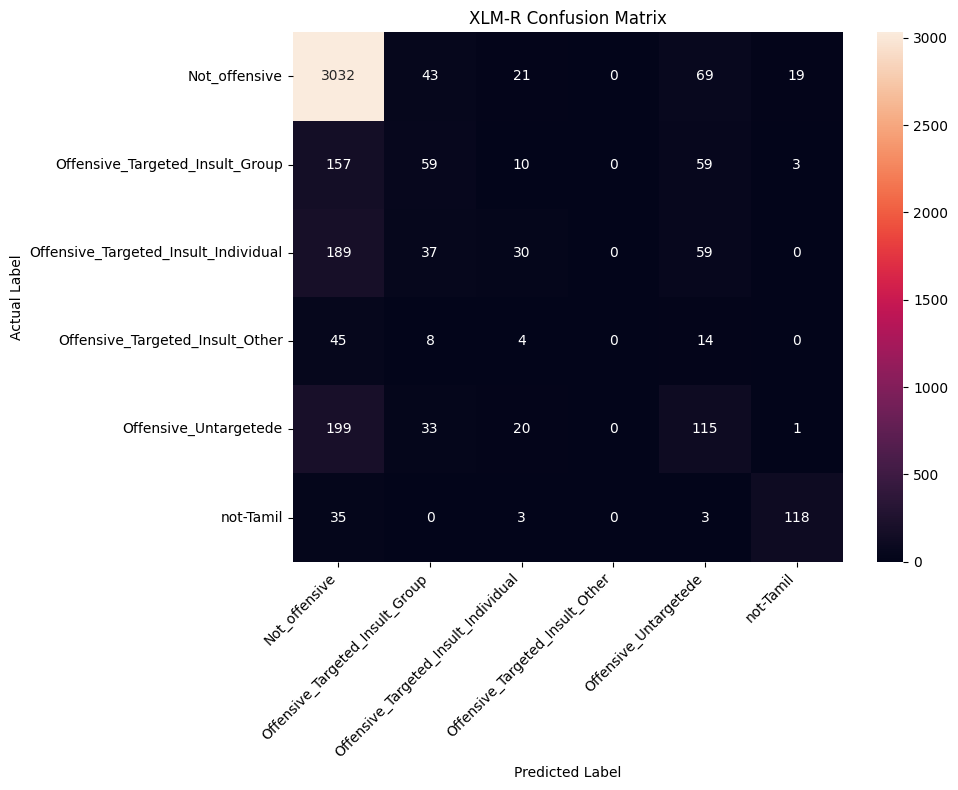

In [72]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("XLM-R Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# 58. Normalized Confusion Matrix

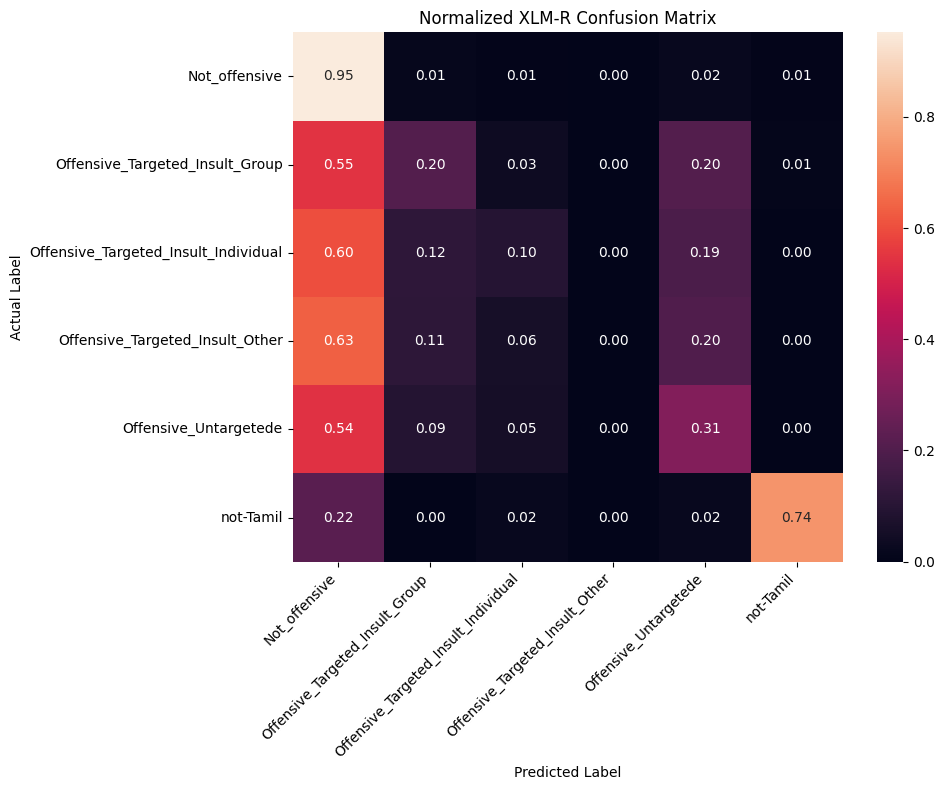

In [73]:
cm_normalized = cm.astype("float") / cm.sum(
    axis=1,
    keepdims=True
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Normalized XLM-R Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# 59. Transformer vs Classical Baseline

In [74]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],

    "Classical Baseline": [
        test_accuracy,
        test_precision_macro,
        test_recall_macro,
        test_f1_macro
    ],

    "XLM-R Transformer": [
        test_results["eval_accuracy"],
        test_results["eval_precision"],
        test_results["eval_recall"],
        test_results["eval_f1"]
    ]
})

print("=" * 60)
print("CLASSICAL BASELINE vs XLM-R TRANSFORMER")
print("=" * 60)

display(comparison_df)

CLASSICAL BASELINE vs XLM-R TRANSFORMER


,Metric,Classical Baseline,XLM-R Transformer
0,Accuracy,0.768301,0.764880
1,Macro Precision,0.544826,0.449194
2,Macro Recall,0.403111,0.384500
3,Macro F1,0.440719,0.401483


# 60. Save Model

In [75]:
SAVE_PATH = "./models/xlmr_offensive_classifier"

os.makedirs(SAVE_PATH, exist_ok=True)

# Save trained model
trainer.save_model(SAVE_PATH)

# Save tokenizer
tokenizer.save_pretrained(SAVE_PATH)

print("=" * 60)
print("FINAL TRANSFORMER MODEL SAVED")
print("=" * 60)
print("Location:", SAVE_PATH)

print("\nSaved files:")

for filename in sorted(os.listdir(SAVE_PATH)):
    print(" -", filename)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

FINAL TRANSFORMER MODEL SAVED
Location: ./models/xlmr_offensive_classifier

Saved files:
 - config.json
 - model.safetensors
 - tokenizer.json
 - tokenizer_config.json
 - training_args.bin


# 62. Final Transformer Configuration Summary

In [77]:
final_configuration = pd.DataFrame({
    "Parameter": [
        "Transformer Model",
        "Tokenizer",
        "Maximum Sequence Length",
        "Epochs",
        "Batch Size",
        "Learning Rate",
        "Weight Decay",
        "Training Dataset",
        "Validation Dataset",
        "Test Dataset",
        "Computational Resource"
    ],

    "Value": [
        MODEL_NAME,
        MODEL_NAME,
        MAX_LENGTH,
        TRANSFORMER_EPOCHS,
        TRANSFORMER_BATCH_SIZE,
        TRANSFORMER_LEARNING_RATE,
        TRANSFORMER_WEIGHT_DECAY,
        f"{len(train_df)} samples",
        f"{len(dev_df)} samples",
        f"{len(test_df)} samples",
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU"
    ]
})

display(final_configuration)

,Parameter,Value
0,Transformer Model,xlm-roberta-base
1,Tokenizer,xlm-roberta-base
2,Maximum Sequence Length,128
3,Epochs,2
4,Batch Size,8
5,Learning Rate,0.00002
6,Weight Decay,0.01
7,Training Dataset,34898 samples
8,Validation Dataset,4380 samples
9,Test Dataset,4385 samples


In [79]:
# Transformer Error Analysis

transformer_error_analysis = pd.DataFrame({
    "text": test_df["text"].values,
    "actual_label": [
        labels[i] for i in y_true
    ],
    "predicted_label": [
        labels[i] for i in y_pred
    ]
})

# Keep only incorrectly classified samples
transformer_errors = transformer_error_analysis[
    transformer_error_analysis["actual_label"] !=
    transformer_error_analysis["predicted_label"]
].copy()

print("Number of Transformer errors:",
      len(transformer_errors))

print("\nFirst 10 Transformer errors:")
display(
    transformer_errors.head(10)
)

Number of Transformer errors: 1031

First 10 Transformer errors:


,text,actual_label,predicted_label
4,suma kaththaatha da sound over a pooda kudaathu pa s3 1 month oda stop aakidum then bairavaa da aaddchi than kaththi kaththi thondaiya kilikatha pa,Offensive_Untargetede,Offensive_Targeted_Insult_Group
5,ஆனவக் கொலைகள் நடக்காவிடில்...நம் அடையாளம் அளிக்கப்படும்... இயக்குனருக்கு வாழ்த்துக்கள்...தமிழ்நாடு முத்தரையர்கள்,Offensive_Targeted_Insult_Group,Not_offensive
8,Power ranger megazord niyabagam vantha hit like,Offensive_Untargetede,Not_offensive
13,0:28 Shaktimaan Parle-G Biscuit SaptuNaanum sinna vayasula jump panni parakka try pannirukken 90's Pasanga Da 🤣,Offensive_Untargetede,Offensive_Targeted_Insult_Group
20,எவனுக்கும் அடங்க மாட்டோம்... எவளுக்கும் மயங்க மாட்டோம்🤙... # நாடக காதல் # கும்பல்களை வேரோடு அழிக்க வந்த # திரௌபதி படத்திற்கு.. தேவேந்திர குல வேளாளர் சார்பாக வாழ்த்துக்கள்.,Offensive_Targeted_Insult_Group,Not_offensive
21,Movie yachum nailla eruka nu papom,Offensive_Untargetede,Not_offensive
22,nice aana teaser starting laa vandha dialogue mgr sir engaveetu Pillai la padina naan anai etal ooda middle lines laa...,Offensive_Targeted_Insult_Other,Not_offensive
35,🤣🤣🤣 video ku dislike pottavangalam vanthu Inka oru like ah thatti vitutu ponga,Offensive_Targeted_Insult_Other,Offensive_Untargetede
40,கோமாளி90'பசங்க வெறித்தனம் இந்த படத்துல தெரியும் டா90'பசங்களோட வலி அப்போ. இப்போ,Not_offensive,Offensive_Targeted_Insult_Group
41,Aathi kanithan 2 paatha maarilla iruku...,Offensive_Targeted_Insult_Individual,Not_offensive


In [80]:
# Save Transformer error analysis

transformer_errors.to_csv(
    "results/xlmr_error_analysis.csv",
    index=False
)

print("Transformer error analysis saved.")

Transformer error analysis saved.


In [81]:
# Save final Transformer evaluation results

transformer_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],

    "XLM-R": [
        test_results["eval_accuracy"],
        test_results["eval_precision"],
        test_results["eval_recall"],
        test_results["eval_f1"]
    ]
})

transformer_results.to_csv(
    "results/xlmr_test_results.csv",
    index=False
)

display(transformer_results)

print("Transformer results saved.")

,Metric,XLM-R
0,Accuracy,0.764880
1,Macro Precision,0.449194
2,Macro Recall,0.384500
3,Macro F1,0.401483


Transformer results saved.
